### Preparación de los datos:

In [22]:
# Cargar dataset
import pandas as pd
import numpy as np

features_df = pd.read_csv("../data/datasets/df_to_train.csv")
features_df.set_index("ECG_ID", inplace=True)

In [23]:
features_df.head()

,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,Sex
ECG_ID,,,,,,,
A00002,0.256824,0.017406,-0.440486,0.662585,0.222963,-0.282507,1
A00003,0.195565,0.027917,0.827458,-0.070707,0.051890,-0.277537,1
A00006,0.212903,0.307385,0.054002,0.055471,0.149587,0.018080,0
A00008,-0.077419,0.078169,0.087648,0.330885,0.079797,0.279721,1
A00009,-0.553763,-0.085222,0.184517,0.026673,-0.081408,0.070555,0


In [33]:
# Creación del modelo (KERAS)
import keras


model = keras.Sequential([
    keras.layers.Input(shape=(6,)),
    keras.layers.Dense(
        16,
        activation='selu',
        kernel_regularizer=keras.regularizers.l2(0.01),
        kernel_initializer="he_normal"
        ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(
        8,
        activation='selu',
        kernel_regularizer=keras.regularizers.l2(0.01),
        kernel_initializer="he_normal"
        ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

In [34]:
# Compilación del modelo


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.BinaryCrossentropy(), # Al ser un clasificador binario, se utiliza esta función de pérdida
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name='precision'),     # 3. Precisión por sexo
        keras.metrics.Recall(name='recall'),        # 4. Sensibilidad por sexo
        keras.metrics.F1Score(name='f1_score'), 
        ]
)

### Creación de los conjuntos de entrenamiento, validación y pruebas

In [35]:
X = features_df.iloc[:, :-1]
y = features_df.iloc[:, -1]

In [36]:
# Entrenamiento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200, batch_size=32)

Epoch 1/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.5577 - f1_score: 0.7110 - loss: 1.3534 - precision: 0.5947 - recall: 0.4822 - val_auc: 0.5935 - val_f1_score: 0.7163 - val_loss: 1.2462 - val_precision: 0.6377 - val_recall: 0.4538
Epoch 2/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.5918 - f1_score: 0.7110 - loss: 1.2820 - precision: 0.6210 - recall: 0.5334 - val_auc: 0.6403 - val_f1_score: 0.7163 - val_loss: 1.1986 - val_precision: 0.6834 - val_recall: 0.5028
Epoch 3/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6050 - f1_score: 0.7110 - loss: 1.2423 - precision: 0.6275 - recall: 0.5631 - val_auc: 0.6689 - val_f1_score: 0.7163 - val_loss: 1.1612 - val_precision: 0.6975 - val_recall: 0.5499
Epoch 4/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6121 - f1_score: 0.7110 - loss: 1.2083 - precision: 0.6271 - recall: 0.5790 - val_auc: 0.6844 - val_f1_score: 0.7163 - val_loss: 1.1320 - val_precision: 0.7037 - val_recall: 0.5730
Epoch 5/200
243/243 ━━━━━━━━

In [37]:
model.history.history.keys()

dict_keys(['auc', 'f1_score', 'loss', 'precision', 'recall', 'val_auc', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])

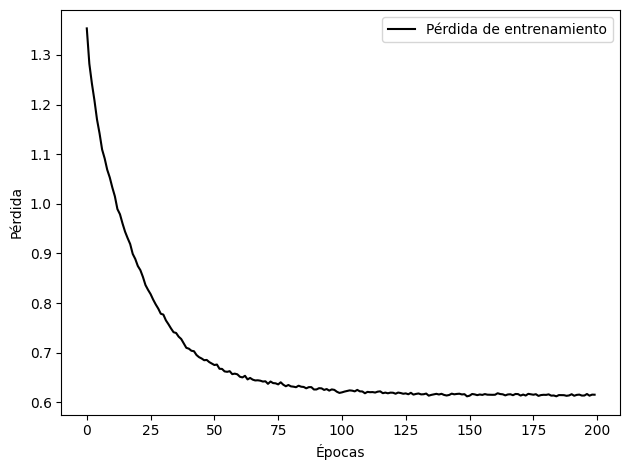

In [38]:
# Graficar las curvas de entrenamiento y validación
import matplotlib.pyplot as plt

history = model.history.history
plt.plot(history['loss'], label='Pérdida de entrenamiento', c='black')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.tight_layout()
plt.show()


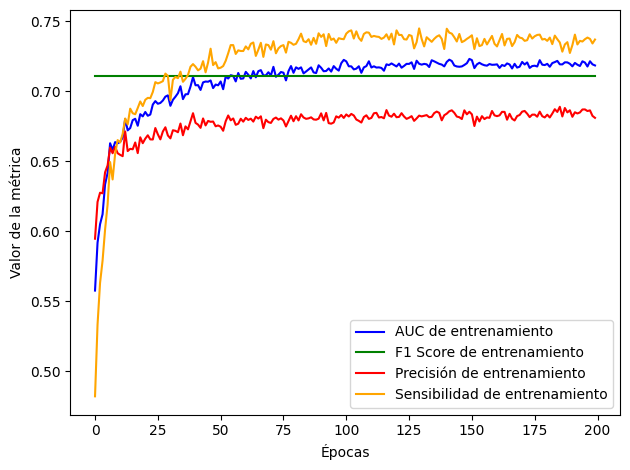

In [39]:
# Graficar métricas de medición:

plt.plot(history['auc'], label='AUC de entrenamiento', c='blue')
plt.plot(history['f1_score'], label='F1 Score de entrenamiento', c='green')
plt.plot(history['precision'], label='Precisión de entrenamiento', c='red')
plt.plot(history['recall'], label='Sensibilidad de entrenamiento', c='orange')
plt.xlabel('Épocas')
plt.ylabel('Valor de la métrica')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.62      0.60      0.61       857
           1       0.69      0.71      0.70      1082

    accuracy                           0.66      1939
   macro avg       0.66      0.65      0.65      1939
weighted avg       0.66      0.66      0.66      1939

[[511 346]
 [311 771]]


In [54]:
# Guardar modelo
keras.saving.save_model(model, "../models/model.keras")